# Stochastic Processes

Markov Chain

In [ ]:
# Import modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math

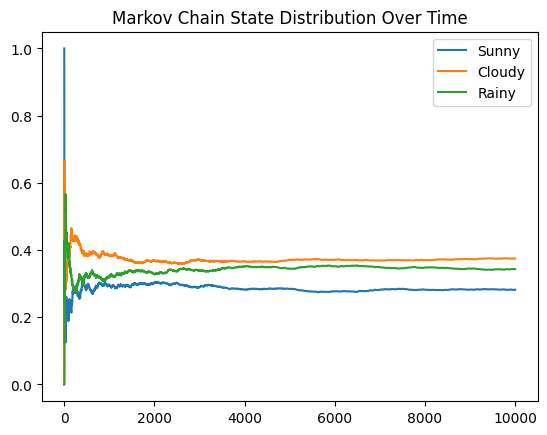

In [ ]:
# Markov chain

states = ["Sunny", "Cloudy", "Rainy"]
transition_matrix  = np.array([
    [0.6, 0.3, 0.1],
    [0.2, 0.5, 0.3],
    [0.1, 0.3, 0.6]
])

n_steps = 10000
current_state = 0
states_list = [current_state]

for i in range(n_steps - 1):
  current_state = np.random.choice([0, 1, 2], p = transition_matrix[current_state])
  states_list.append(current_state)

frequency_count = np.zeros((3, n_steps))
for j, k in enumerate(states_list):
  frequency_count[k, j] += 1

# Note: j is the time index, and k is the state at time j

cumulative_freq = np.cumsum(frequency_count, axis=1) / np.arange(1, n_steps + 1)

# Plot results

for j, state in enumerate(states):
  plt.plot(cumulative_freq[j], label = state)
plt.title("Markov Chain State Distribution Over Time")
plt.legend()
plt.show()

In [ ]:
# Alternatively, if we want our output to be a chain of states, we can do the following:

# Setup

states = {0: "Sunny", 1: "Cloudy", 2: "Rainy"}

transition_matrix  = np.array([
    [0.6, 0.3, 0.1],
    [0.2, 0.5, 0.3],
    [0.1, 0.3, 0.6]
])

# Random Walk

n_steps = 50
start_state = 0
print(states[start_state], "-->", end = " ")
prev_state = start_state

while n_steps - 1:
  current_state = np.random.choice([0, 1, 2], p = transition_matrix[prev_state])
  print(states[current_state], "-->", end = " ")
  prev_state = current_state
  n_steps -= 1

print("STOP")

Sunny --> Sunny --> Rainy --> Rainy --> Rainy --> Rainy --> Rainy --> Cloudy --> Cloudy --> Cloudy --> Cloudy --> Cloudy --> Cloudy --> Rainy --> Cloudy --> Cloudy --> Rainy --> Rainy --> Cloudy --> Rainy --> Rainy --> Rainy --> Cloudy --> Rainy --> Rainy --> Rainy --> Rainy --> Cloudy --> Cloudy --> Rainy --> Cloudy --> Rainy --> Rainy --> Rainy --> Cloudy --> Cloudy --> Cloudy --> Cloudy --> Sunny --> Sunny --> Cloudy --> Rainy --> Rainy --> Cloudy --> Cloudy --> Cloudy --> Sunny --> Rainy --> Rainy --> Cloudy --> STOP


In [ ]:
# Compute the probabilities of each state

n_steps = 100000
start_state = 0
prob = np.zeros(3) # Generates the 0 vector in R^3
prob[start_state] = 1
prev_state = start_state

i = 0
while i < n_steps:
  current_state = np.random.choice([0, 1, 2], p = transition_matrix[prev_state])
  prob[current_state] += 1
  prev_state = current_state
  i += 1

print(f"Probability of Sunny, Cloudy, and Rainy states: {prob / n_steps}, respectively")

# This solution is an example of a Monte Carlo process

Probability of Sunny, Cloudy, and Rainy states: [0.28211 0.37259 0.34531], respectively


Monte Carlo method

In [ ]:
# Simulating the overview section of https://en.wikipedia.org/wiki/Monte_Carlo_method

# Goal: estimate pi using the Monte Carlo method
# Recall: pi = 4*desired points / total number of points,
# where desired points are points that fall in the unit circle in the first quadrant

# Parameters

total_points = 10000000
desired_points = 0

# Randomly plot points

for i in range(total_points):
  x = random.random()
  y= random.random()

# Check if our random point is a desired point

  if x**2 + y**2 < 1:
    desired_points += 1

pi = float(4 * desired_points / total_points)

print(f"Number of desired points: {desired_points}")
print(f"Our estimate of pi: {pi}")
print(f"Actual value of pi: {math.pi}")

Number of desired points: 7855200
Our estimate of pi: 3.14208
Actual value of pi: 3.141592653589793


In [ ]:
# Estimating pi with n points

def estimate_pi(n):
  desired_points = 0
  for i in range(n):
    x = random.random()
    y = random.random()
    if x**2 + y**2 < 1:
      desired_points += 1
  return float(4 * desired_points / n)

pi_estimate = estimate_pi(10000000)

print(f"Our estimate of pi: {pi_estimate}")
print(f"Actual value of pi: {math.pi}")

Our estimate of pi: 3.1416444
Actual value of pi: 3.141592653589793


Random Walk simulations for 1, 2, and 3 dimensions.

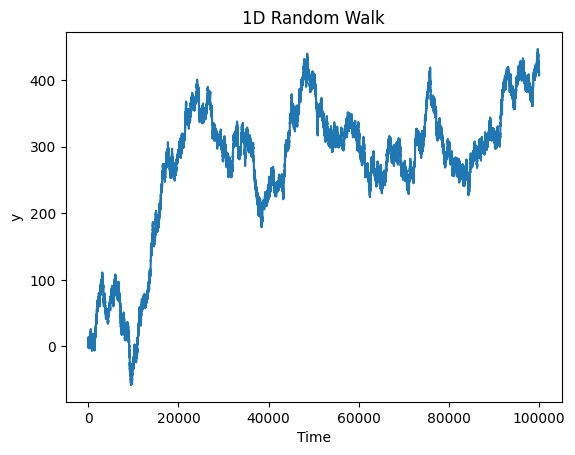

In [ ]:
# 1D Random Walk

n = 100000
y = 0
time = np.arange(n+1)
positions = [y]
directions = ["UP", "DOWN"]

for i in range(1, n+1):
  step = random.choice(directions)
  if step == "UP":
    y += 1
  elif step == "DOWN":
    y -= 1
  positions.append(y)

# Plot results

plt.plot(time, positions)
plt.title("1D Random Walk")
plt.xlabel("Time")
plt.ylabel("y")
plt.show()

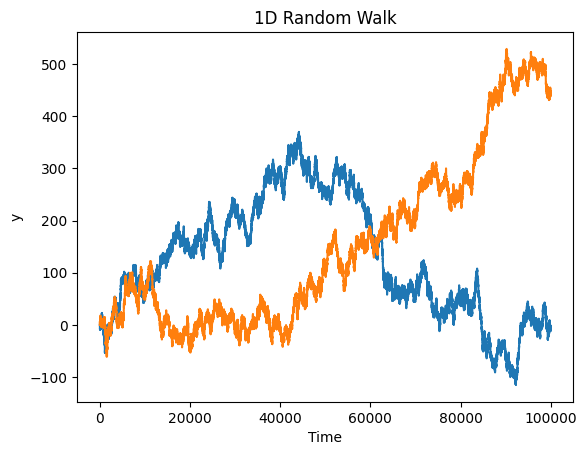

In [ ]:
# 1D Random Walk as a function
# With this, we can plot several random walks at once

def randomwalk_1D(n):
  y = 0
  time = np.arange(n+1)
  positions = [y]
  directions = ["UP", "DOWN"]

  for i in range(1, n+1):
    step = random.choice(directions)
    if step == "UP":
      y += 1
    elif step == "DOWN":
      y -= 1
    positions.append(y)
  return time, positions

randomwalk1 = randomwalk_1D(100000)
randomwalk2 = randomwalk_1D(100000)

# Plot results

plt.plot(randomwalk1[0], randomwalk1[1])
plt.plot(randomwalk2[0], randomwalk2[1])
plt.title("1D Random Walk")
plt.xlabel("Time")
plt.ylabel("y")
plt.show()

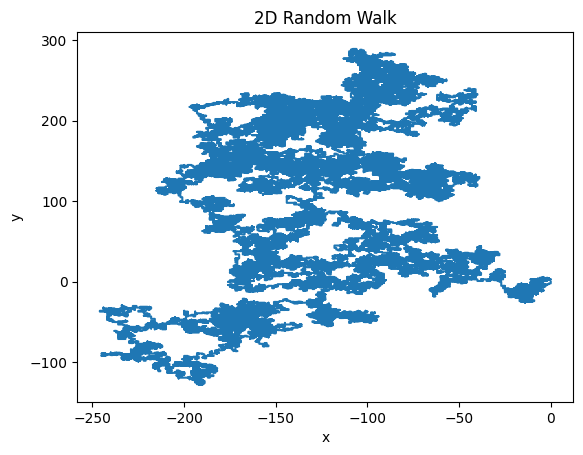

In [ ]:
# 2D Random Walk

def randomwalk_2D(n):
  x = np.zeros(n) # 1xn zero vector
  y = np.zeros(n)
  directions = ["UP", "DOWN", "LEFT", "RIGHT"]
  for i in range(1, n):
    step = random.choice(directions)
    if step == "UP":
      x[i] = x[i-1]
      y[i] = y[i-1] + 1
    elif step == "DOWN":
      x[i] = x[i-1]
      y[i] = y[i-1] - 1
    elif step == "LEFT":
      x[i] = x[i-1] - 1
      y[i] = y[i-1]
    elif step == "RIGHT":
      x[i] = x[i-1] + 1
      y[i] = y[i-1]
  return x, y

# Plot results

x_points, y_points = randomwalk_2D(100000)
plt.plot(x_points, y_points)
plt.title("2D Random Walk")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

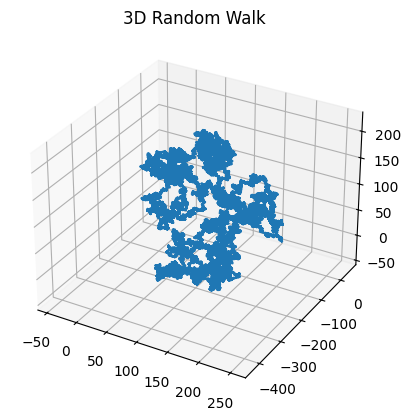

In [ ]:
# 3D Random Walk

def randomwalk_3D(n):
  x = np.zeros(n) # 1xn zero vector
  y = np.zeros(n)
  z = np.zeros(n)
  directions = ["UP", "DOWN", "LEFT", "RIGHT", "Z-POS", "Z-NEG"]

  for i in range(1, n):
    step = random.choice(directions)
    if step == "UP":
      x[i] = x[i-1]
      y[i] = y[i-1] + 1
      z[i] = z[i-1]
    elif step == "DOWN":
      x[i] = x[i-1]
      y[i] = y[i-1] - 1
      z[i] = z[i-1]
    elif step == "LEFT":
      x[i] = x[i-1] - 1
      y[i] = y[i-1]
      z[i] = z[i-1]
    elif step == "RIGHT":
      x[i] = x[i-1] + 1
      y[i] = y[i-1]
      z[i] = z[i-1]
    elif step == "Z-POS":
      x[i] = x[i-1]
      y[i] = y[i-1]
      z[i] = z[i-1] + 1
    elif step == "Z-NEG":
      x[i] = x[i-1]
      y[i] = y[i-1]
      z[i] = z[i-1] - 1
  return x, y, z

# Plot results

x_points, y_points, z_points = randomwalk_3D(100000)
axes = plt.subplot(1, 1, 1, projection='3d')
axes.plot3D(x_points, y_points, z_points)
axes.scatter(x_points[-1], y_points[-1], z_points[-1])
axes.set_title("3D Random Walk")
plt.show()

# Structurally, the code is similar to that of the 2-dimensional case
# Higher dimensions should follow a similar process